Supplementary Code S7. Stepwise ablation analysis under fixed S2 winner configurations

Purpose.
This notebook implements a stepwise ablation study requested during peer review to assess the stability and driver dependence of the winner models identified in Supplementary Code S2 and summarized in S5–S6. The analysis is explicitly diagnostic: it evaluates how strongly predictive performance depends on a small subset of dominant predictors and whether near-perfect discrimination is robust to progressive feature removal.

Relationship to prior scripts.

S2 defines the nested cross-validation protocol and selects winner models (model class and hyperparameters) for each feature-set variant.

S5 summarizes performance–complexity trade-offs using governed feature sets and out-of-fold (OOF) estimates.

S6 audits potential leakage and identifies dominant performance drivers.

S7 extends these diagnostics by explicitly re-running the S2 outer-CV protocol after stepwise removal of top-ranked predictors, while keeping all other modeling choices fixed.

Key principles (journal-ready).

Uses exactly the same target definition, cohort filtering, governed feature sets, model classes, and hyperparameters as in S2/S5/S6.

No re-tuning or re-selection of models is performed; S7 does not define new “best” models.

Performance is always estimated using outer-fold cross-validation, consistent with the original S2 evaluation strategy.

Feature removal order is determined using leakage-safe permutation importance computed exclusively on outer test folds.

All-missing and constant predictors are removed prior to modeling to prevent silent preprocessing artifacts.

Methods implemented in S7

For each feature-set variant (FULL, CLINICAL, BIOMARKERS), the notebook performs:

Baseline re-evaluation under fixed S2 configuration.
The winner model (class and hyperparameters) is re-evaluated using outer-fold CV to confirm consistency with S2/S5 performance estimates.

Leakage-safe feature ranking.
Predictors are ranked using outer-fold permutation importance, yielding an average “ROC AUC drop” that reflects contribution to generalization performance without training-set leakage.

Stepwise ablation with S2 protocol re-run.
Starting from the full governed feature set, the top-ranked predictor is removed, and the outer-CV evaluation is re-run from scratch using the same fixed model configuration.
This procedure is repeated sequentially for the top k drivers (up to a predefined maximum), ensuring that performance changes are attributable solely to feature removal.

Cross-variant comparison of performance degradation.
The resulting ablation curves quantify how rapidly discrimination deteriorates as dominant predictors are removed, enabling direct comparison of driver concentration and robustness across FULL, CLINICAL, and BIOMARKERS variants.

Importantly, the feature-importance ranking is computed once on the full feature set and is not re-estimated after each removal. This design choice reflects the diagnostic goal of identifying dominant drivers rather than optimizing post-ablation models.

Inputs (from S2–S6 workflow)

Required:

processed_dataset.csv

winner_model_by_variant.csv

nestedcv_bestparams_all_variants.csv

features_used_FULL.csv

features_used_CLINICAL.csv

features_used_BIOMARKERS.csv

Optional:

audit_nonnumeric_features.csv

All inputs are identical to, or derived from, those used in S5–S6, ensuring full pipeline consistency.

Outputs

Per-variant tables:

S7_<VARIANT>_perm_rank_outer.csv — leakage-safe permutation importance ranking

S7_<VARIANT>_ablation_rerunS2.csv — stepwise ablation results with outer-CV metrics

Cross-variant summaries:

S7_baseline_metrics.csv — baseline outer-CV performance under fixed S2 configuration

S7_ablation_rerunS2_all_variants.csv — combined ablation results across variants

S7_variant_matrix_diagnostics.csv — diagnostic summary of effective feature counts after preprocessing

S7_run_log.json — fully auditable record of inputs, configuration, and outputs

Figures:

S7_ablation_curve_<VARIANT>.png — ROC AUC vs number of removed predictors

Interpretation note.
S7 is designed as a diagnostic sensitivity analysis. The ablation results do not define alternative deployable models but provide transparent evidence of how strongly reported performance depends on a small number of predictors, supporting cautious interpretation of near-perfect internal discrimination.

## Setup + results catalogs

In [1]:
from __future__ import annotations

import json
from collections import Counter
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score, matthews_corrcoef

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

cv_outer = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

ROOT = Path("/content") if Path("/content").exists() else Path.cwd()

OUT_DIR = ROOT / "results" / "S7_ablation"
TAB_DIR = OUT_DIR / "tables"
FIG_DIR = OUT_DIR / "figures"
LOG_DIR = OUT_DIR / "logs"
for d in (TAB_DIR, FIG_DIR, LOG_DIR):
    d.mkdir(parents=True, exist_ok=True)

print("ROOT:", ROOT)
print("Writing outputs to:", OUT_DIR.resolve())


ROOT: /content
Writing outputs to: /content/results/S7_ablation


## Finder + loadery

In [2]:
SEARCH_ROOTS = [
    ROOT,
    ROOT / "results",
    ROOT / "results" / "S1_preprocessing",
    ROOT / "results" / "S2_nestedcv",
    ROOT / "results" / "S3_benchmark_summary",
    ROOT / "results" / "S4_calibration_thresholds",
    ROOT / "results" / "S5_tradeoff",
    ROOT / "results" / "S6_leakage_audit",
    Path("/mnt/data"),
    ROOT / "drive",
    ROOT / "drive" / "MyDrive",
]

def find_file(filename: str, roots: list[Path]) -> Path:
    for r in roots:
        p = r / filename
        if p.exists():
            return p
    for r in roots:
        if r.exists():
            hits = list(r.rglob(filename))
            if hits:
                hits = sorted(hits, key=lambda x: len(str(x)))
                return hits[0]
    raise FileNotFoundError(
        f"Missing required file: {filename}\nSearched in:\n - " + "\n - ".join(map(str, roots))
    )

def read_csv_required(name: str) -> tuple[pd.DataFrame, Path]:
    p = find_file(name, SEARCH_ROOTS)
    df = pd.read_csv(p)
    print(f"Loaded: {p} | shape={df.shape}")
    return df, p

def load_feature_list(path: Path) -> list[str]:
    fdf = pd.read_csv(path)
    fdf.columns = [c.strip() for c in fdf.columns]
    for col in ["feature", "features", "feature_name", "column", "variable", "var", "name"]:
        if col in fdf.columns:
            feats = fdf[col].astype(str).str.strip().tolist()
            return [f for f in feats if f and f.lower() != "nan"]
    feats = fdf.iloc[:, 0].astype(str).str.strip().tolist()
    return [f for f in feats if f and f.lower() != "nan"]


## Loading artifacts + governed feature lists

In [3]:
df, path_processed = read_csv_required("processed_dataset.csv")
winner_df, path_winners = read_csv_required("winner_model_by_variant.csv")
bestparams_df, path_best = read_csv_required("nestedcv_bestparams_all_variants.csv")

p_full = find_file("features_used_FULL.csv", SEARCH_ROOTS)
p_clin = find_file("features_used_CLINICAL.csv", SEARCH_ROOTS)
p_bio  = find_file("features_used_BIOMARKERS.csv", SEARCH_ROOTS)

features_used = {
    "FULL": load_feature_list(p_full),
    "CLINICAL": load_feature_list(p_clin),
    "BIOMARKERS": load_feature_list(p_bio),
}

print("Governed feature counts:")
for v in ["FULL", "CLINICAL", "BIOMARKERS"]:
    print(f"  {v}: {len(features_used[v])}")


Loaded: /content/processed_dataset.csv | shape=(152, 117)
Loaded: /content/winner_model_by_variant.csv | shape=(3, 8)
Loaded: /content/nestedcv_bestparams_all_variants.csv | shape=(60, 5)
Governed feature counts:
  FULL: 69
  CLINICAL: 58
  BIOMARKERS: 10


## Target

In [4]:
TARGET_COL = "typ_zawalu"
if TARGET_COL not in df.columns:
    raise ValueError(f"TARGET_COL='{TARGET_COL}' not found in processed_dataset.csv")

labels = df[TARGET_COL].astype(str).str.strip()
allowed = {"STEMI", "NSTEMI"}

df = df.loc[labels.isin(allowed)].copy()
y = (df[TARGET_COL].astype(str).str.strip() == "STEMI").astype(int).values

print("TARGET_COL:", TARGET_COL)
print("Task: STEMI vs NSTEMI (positive=STEMI)")
print("Class counts:\n", pd.Series(y).value_counts())
print("Positive rate:", float(np.mean(y)))


for k in features_used:
    features_used[k] = [f for f in features_used[k] if f != TARGET_COL]


TARGET_COL: typ_zawalu
Task: STEMI vs NSTEMI (positive=STEMI)
Class counts:
 0    32
1    25
Name: count, dtype: int64
Positive rate: 0.43859649122807015


## NONNUMERIC audit

In [5]:
NONNUMERIC_FEATURES = set()
path_audit = None
try:
    audit_df, path_audit = read_csv_required("audit_nonnumeric_features.csv")
    cand = ["feature","feature_name","column","variable","var","name"]
    col = next((c for c in cand if c in audit_df.columns), None)
    if col is None:
        col = audit_df.columns[0]
    NONNUMERIC_FEATURES = set(audit_df[col].astype(str).tolist())
    print("Loaded NONNUMERIC_FEATURES:", len(NONNUMERIC_FEATURES))
except FileNotFoundError:
    print("NOTE: audit_nonnumeric_features.csv not found (OK).")


NOTE: audit_nonnumeric_features.csv not found (OK).


## BEST_PARAMS (JSON best_params) + make_pipeline

In [6]:
WINNER_MODELS = {row["variant"]: row["model"] for _, row in winner_df.iterrows()}

def aggregate_best_params_json(variant: str, model_key: str) -> dict:
    dfp = bestparams_df[(bestparams_df["variant"] == variant) & (bestparams_df["model"] == model_key)].copy()
    if dfp.empty:
        print(f"WARNING: No bestparams rows for (variant={variant}, model={model_key}). Using empty params.")
        return {}
    if "best_params" not in dfp.columns:
        raise ValueError("nestedcv_bestparams_all_variants.csv must contain column 'best_params' (JSON string).")

    params_list = []
    for s in dfp["best_params"].dropna().tolist():
        params_list.append(json.loads(s))

    all_keys = set().union(*params_list) if params_list else set()
    out = {}
    for k in all_keys:
        vals = [p.get(k) for p in params_list if k in p]
        cnt = Counter([json.dumps(v, sort_keys=True) for v in vals])
        mode_str = cnt.most_common(1)[0][0]
        out[k] = json.loads(mode_str)
    return out

BEST_PARAMS = {v: aggregate_best_params_json(v, WINNER_MODELS[v]) for v in WINNER_MODELS.keys()}

print("Winner models:", WINNER_MODELS)
print("Best params (aggregated):", BEST_PARAMS)

def make_pipeline(variant_name: str) -> Pipeline:
    model_key = WINNER_MODELS[variant_name]
    params = BEST_PARAMS.get(variant_name, {}).copy()
    params_clean = {k.replace("clf__", ""): v for k, v in params.items()}

    if model_key in ["LR", "LogReg", "LOGREG", "LOGISTIC"]:
        clf = LogisticRegression(max_iter=5000, random_state=RANDOM_STATE, **params_clean)
        use_scaler = True
    elif model_key == "RF":
        clf = RandomForestClassifier(random_state=RANDOM_STATE, **params_clean)
        use_scaler = False
    elif model_key in ["SVM", "LinearSVM"]:
        params_clean["probability"] = True
        clf = SVC(random_state=RANDOM_STATE, **params_clean)
        use_scaler = True
    elif model_key == "KNN":
        clf = KNeighborsClassifier(**params_clean)
        use_scaler = True
    elif model_key == "NB":
        clf = GaussianNB(**params_clean)
        use_scaler = False
    else:
        raise ValueError(f"Unsupported model key: {model_key}")

    steps = [("imputer", SimpleImputer(strategy="median"))]
    if use_scaler:
        steps.append(("scaler", StandardScaler()))
    preprocess = Pipeline(steps)

    return Pipeline([("preprocess", preprocess), ("clf", clf)])


Winner models: {'BIOMARKERS': 'RF', 'CLINICAL': 'RF', 'FULL': 'RF'}
Best params (aggregated): {'BIOMARKERS': {'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2, 'clf__max_depth': None}, 'CLINICAL': {'clf__max_features': 'log2', 'clf__min_samples_leaf': 4, 'clf__min_samples_split': 2, 'clf__max_depth': None}, 'FULL': {'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2, 'clf__max_depth': None}}


## Construction of matrix X (binary recode + drop all-NaN/constant)

In [7]:
def _normalize_str_series(s: pd.Series) -> pd.Series:
    return (
        s.astype(str)
         .str.strip()
         .str.lower()
         .str.replace(",", ".", regex=False)
    )

YES_SET = {"yes","y","true","t","1","tak","on","present","positive","pos"}
NO_SET  = {"no","n","false","f","0","nie","off","absent","negative","neg"}

def _try_map_binary_object(col: pd.Series) -> tuple[pd.Series, bool]:
    norm = _normalize_str_series(col)
    uniq = sorted(norm.dropna().unique().tolist())
    if len(uniq) == 0:
        return col, False
    if len(set(uniq)) <= 2 and all(u in (YES_SET | NO_SET) for u in uniq):
        def map_one(v):
            if pd.isna(v): return np.nan
            vv = str(v).strip().lower()
            if vv in YES_SET: return 1
            if vv in NO_SET:  return 0
            return np.nan
        return norm.map(map_one).astype(float), True
    return col, False

def build_matrix(df_in: pd.DataFrame, feats: list[str], variant_name: str):
    feats = [f for f in feats if f in df_in.columns and f != TARGET_COL]
    feats = [f for f in feats if f not in NONNUMERIC_FEATURES]

    Xdf = df_in[feats].copy()


    recoded = 0
    for c in Xdf.columns:
        if Xdf[c].dtype == "object" or str(Xdf[c].dtype).startswith("bool"):
            mapped, ok = _try_map_binary_object(Xdf[c])
            if ok:
                Xdf[c] = mapped
                recoded += 1


    for c in Xdf.columns:
        if Xdf[c].dtype == "object":
            Xdf[c] = _normalize_str_series(Xdf[c])
        Xdf[c] = pd.to_numeric(Xdf[c], errors="coerce")


    nan_rate = Xdf.isna().mean()
    all_nan = nan_rate[nan_rate == 1.0].index.tolist()

    nunique = Xdf.nunique(dropna=True)
    constant = nunique[nunique <= 1].index.tolist()

    dropped = sorted(set(all_nan + constant))
    if dropped:
        pd.DataFrame({"feature": dropped}).to_csv(TAB_DIR / f"S7_{variant_name}_dropped_empty_or_constant.csv", index=False)
        Xdf = Xdf.drop(columns=dropped)

    diag = {
        "variant": variant_name,
        "n_governed_present": int(len(feats)),
        "n_recoded_binary": int(recoded),
        "n_dropped_empty_or_constant": int(len(dropped)),
        "n_used_matrix": int(Xdf.shape[1]),
    }
    return Xdf.values, np.array(Xdf.columns.tolist()), diag

variants_cfg = {}
diag_rows = []
for v in ["FULL", "CLINICAL", "BIOMARKERS"]:
    Xv, fn, diag = build_matrix(df, features_used[v], v)
    variants_cfg[v] = {"X": Xv, "features": fn}
    diag_rows.append(diag)

diag_df = pd.DataFrame(diag_rows).sort_values("variant").reset_index(drop=True)
diag_df.to_csv(TAB_DIR / "S7_variant_matrix_diagnostics.csv", index=False)
print("Saved:", TAB_DIR / "S7_variant_matrix_diagnostics.csv")
display(diag_df)


Saved: /content/results/S7_ablation/tables/S7_variant_matrix_diagnostics.csv


,variant,n_governed_present,n_recoded_binary,n_dropped_empty_or_constant,n_used_matrix
0,BIOMARKERS,10,0,0,10
1,CLINICAL,58,20,16,42
2,FULL,69,20,16,53


## Outer-CV metryki (fixed winner params), OOF probs

In [8]:
def outer_cv_fixed(pipe: Pipeline, X: np.ndarray, y: np.ndarray, cv):
    aucs, mccs = [], []
    oof_probs = np.zeros(len(y), dtype=float)

    for tr, te in cv.split(X, y):
        pipe.fit(X[tr], y[tr])
        probs = pipe.predict_proba(X[te])[:, 1]
        oof_probs[te] = probs

        aucs.append(roc_auc_score(y[te], probs))
        preds = (probs >= 0.5).astype(int)
        mccs.append(matthews_corrcoef(y[te], preds))

    return oof_probs, {
        "auc_mean": float(np.mean(aucs)),
        "auc_sd": float(np.std(aucs, ddof=1)),
        "mcc_mean": float(np.mean(mccs)),
        "mcc_sd": float(np.std(mccs, ddof=1)),
        "auc_oof": float(roc_auc_score(y, oof_probs))
    }


## Outer-fold permutation ranking

In [9]:
def outer_fold_perm_ranking(pipe: Pipeline, X: np.ndarray, y: np.ndarray, feature_names: np.ndarray, cv):
    importances = np.zeros(X.shape[1], dtype=float)

    for tr, te in cv.split(X, y):
        pipe.fit(X[tr], y[tr])
        res = permutation_importance(
            pipe, X[te], y[te],
            scoring="roc_auc",
            n_repeats=30,
            random_state=RANDOM_STATE
        )
        importances += res.importances_mean

    importances /= cv.get_n_splits()
    df_rank = (pd.DataFrame({"feature": feature_names, "perm_auc_drop": importances})
                 .sort_values("perm_auc_drop", ascending=False)
                 .reset_index(drop=True))
    return df_rank


## Ablation rerun

In [10]:
def ablation_rerun_s2style(variant_name: str, Xv: np.ndarray, feats: np.ndarray, y: np.ndarray, max_remove: int = 20):
    if Xv.shape[1] < 2:
        print(f"[{variant_name}] Skipping ablation: <2 features available.")
        return pd.DataFrame()

    pipe_base = make_pipeline(variant_name)


    _, baseline = outer_cv_fixed(pipe_base, Xv, y, cv_outer)


    df_rank = outer_fold_perm_ranking(pipe_base, Xv, y, feats, cv_outer)
    rank_path = TAB_DIR / f"S7_{variant_name}_perm_rank_outer.csv"
    df_rank.to_csv(rank_path, index=False)
    print("Saved:", rank_path)

    max_remove_safe = min(max_remove, Xv.shape[1] - 1)
    ranked = df_rank["feature"].tolist()[:max_remove_safe]

    rows = [{
        "variant": variant_name,
        "k_removed": 0,
        "removed_feature": "NONE",
        **baseline
    }]

    current_X = Xv.copy()
    current_feats = feats.copy()

    for k, f_remove in enumerate(ranked, start=1):
        if current_X.shape[1] <= 1:
            break

        idx = list(current_feats).index(f_remove)
        current_X = np.delete(current_X, idx, axis=1)
        current_feats = np.delete(current_feats, idx)

        pipe_k = make_pipeline(variant_name)
        _, met_k = outer_cv_fixed(pipe_k, current_X, y, cv_outer)

        rows.append({
            "variant": variant_name,
            "k_removed": k,
            "removed_feature": f_remove,
            **met_k
        })

        print(f"[{variant_name}] removed {k:02d}: {f_remove} -> AUC_mean={met_k['auc_mean']:.3f} | AUC_oof={met_k['auc_oof']:.3f}")

    df_ab = pd.DataFrame(rows)
    out_path = TAB_DIR / f"S7_{variant_name}_ablation_rerunS2.csv"
    df_ab.to_csv(out_path, index=False)
    print("Saved:", out_path)

    return df_ab


## Running ablation for all variants + collective recording

In [11]:
all_dfs = []
baseline_rows = []

for v in ["FULL", "CLINICAL", "BIOMARKERS"]:
    Xv = variants_cfg[v]["X"]
    feats = variants_cfg[v]["features"]

    if Xv.shape[1] < 2:
        print(f"[{v}] Skipping: not enough features after filtering.")
        continue

    df_ab = ablation_rerun_s2style(v, Xv, feats, y, max_remove=20)
    if not df_ab.empty:
        all_dfs.append(df_ab)

        baseline_rows.append({
            "variant": v,
            "winner_model": WINNER_MODELS.get(v),
            "n_features_effective": int(Xv.shape[1]),
            "auc_mean_baseline": float(df_ab.loc[df_ab["k_removed"] == 0, "auc_mean"].iloc[0]),
            "auc_oof_baseline": float(df_ab.loc[df_ab["k_removed"] == 0, "auc_oof"].iloc[0]),
            "mcc_mean_baseline": float(df_ab.loc[df_ab["k_removed"] == 0, "mcc_mean"].iloc[0]),
        })

df_all = pd.concat(all_dfs, ignore_index=True) if all_dfs else pd.DataFrame()
all_path = TAB_DIR / "S7_ablation_rerunS2_all_variants.csv"
df_all.to_csv(all_path, index=False)
print("Saved:", all_path)

df_base = pd.DataFrame(baseline_rows).sort_values("variant").reset_index(drop=True)
base_path = TAB_DIR / "S7_baseline_metrics.csv"
df_base.to_csv(base_path, index=False)
print("Saved:", base_path)

display(df_base)


Saved: /content/results/S7_ablation/tables/S7_FULL_perm_rank_outer.csv
[FULL] removed 01: 92_kda_pro_mmp_9 -> AUC_mean=0.941 | AUC_oof=0.913
[FULL] removed 02: 72_kda_pro_mmp_2 -> AUC_mean=0.858 | AUC_oof=0.800
[FULL] removed 03: emmprin -> AUC_mean=0.691 | AUC_oof=0.653
[FULL] removed 04: wyniki_fgf23_pg_ml -> AUC_mean=0.646 | AUC_oof=0.627
[FULL] removed 05: bmi -> AUC_mean=0.664 | AUC_oof=0.674
[FULL] removed 06: bb -> AUC_mean=0.660 | AUC_oof=0.669
[FULL] removed 07: arb -> AUC_mean=0.564 | AUC_oof=0.574
[FULL] removed 08: crp_5_zapalenie -> AUC_mean=0.649 | AUC_oof=0.630
[FULL] removed 09: cad -> AUC_mean=0.658 | AUC_oof=0.668
[FULL] removed 10: cukrzyca_dm -> AUC_mean=0.699 | AUC_oof=0.719
[FULL] removed 11: crt_d_device -> AUC_mean=0.658 | AUC_oof=0.660
[FULL] removed 12: ile_lat_mizdzyca_konczyn -> AUC_mean=0.631 | AUC_oof=0.621
[FULL] removed 13: ile_lat_miazdzyca_t_szyjnych -> AUC_mean=0.656 | AUC_oof=0.642
[FULL] removed 14: ile_lat_1 -> AUC_mean=0.722 | AUC_oof=0.688
[FULL]

,variant,winner_model,n_features_effective,auc_mean_baseline,auc_oof_baseline,mcc_mean_baseline
0,BIOMARKERS,RF,10,0.948095,0.914375,0.689877
1,CLINICAL,RF,42,0.561905,0.588750,0.139319
2,FULL,RF,53,0.994286,0.996875,0.967332


## Charts: AUC vs k_removed

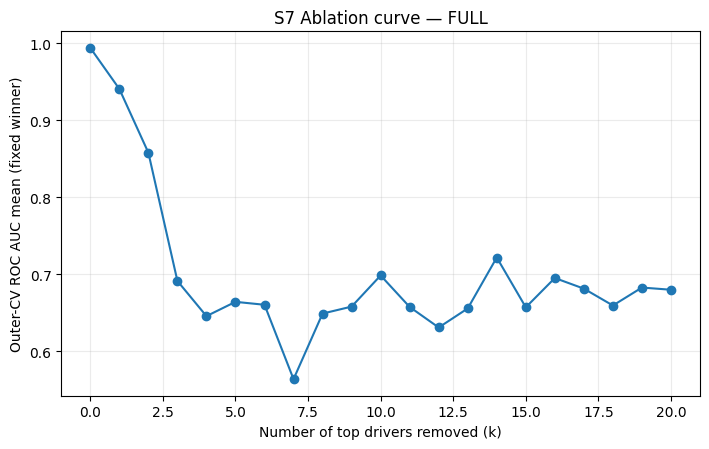

Saved: /content/results/S7_ablation/figures/S7_ablation_curve_FULL.png


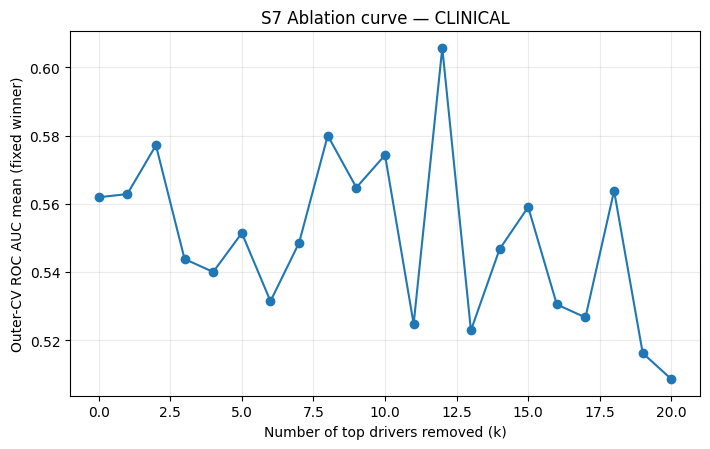

Saved: /content/results/S7_ablation/figures/S7_ablation_curve_CLINICAL.png


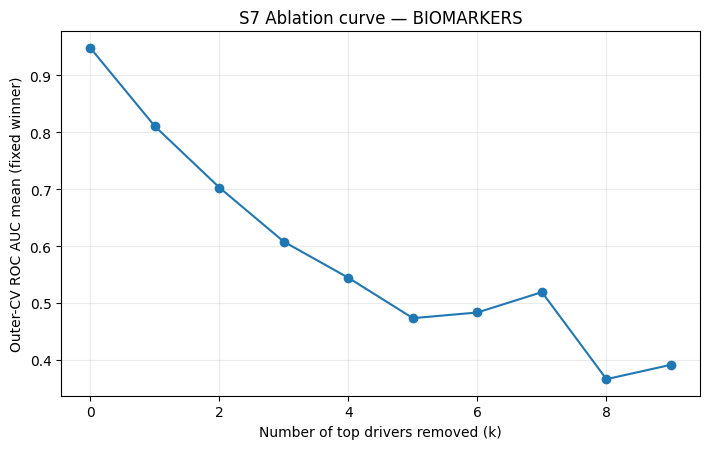

Saved: /content/results/S7_ablation/figures/S7_ablation_curve_BIOMARKERS.png


In [12]:
if df_all.empty:
    print("No ablation results to plot.")
else:
    for v in df_all["variant"].unique():
        sub = df_all[df_all["variant"] == v].sort_values("k_removed")
        plt.figure(figsize=(7.2, 4.6))
        plt.plot(sub["k_removed"], sub["auc_mean"], marker="o")
        plt.xlabel("Number of top drivers removed (k)")
        plt.ylabel("Outer-CV ROC AUC mean (fixed winner)")
        plt.grid(True, alpha=0.25)
        plt.title(f"S7 Ablation curve — {v}")

        fig_path = FIG_DIR / f"S7_ablation_curve_{v}.png"
        plt.tight_layout()
        plt.savefig(fig_path, dpi=300)
        plt.show()
        print("Saved:", fig_path)


## Run log

In [13]:
run_log = {
    "created_at": datetime.utcnow().isoformat() + "Z",
    "random_state": RANDOM_STATE,
    "cv_outer": {"type":"StratifiedKFold","n_splits":5,"shuffle":True,"random_state":RANDOM_STATE},
    "inputs": {
        "processed_dataset.csv": str(path_processed),
        "winner_model_by_variant.csv": str(path_winners),
        "nestedcv_bestparams_all_variants.csv": str(path_best),
        "features_used_FULL.csv": str(p_full),
        "features_used_CLINICAL.csv": str(p_clin),
        "features_used_BIOMARKERS.csv": str(p_bio),
        "audit_nonnumeric_features.csv": str(path_audit) if path_audit else None,
    },
    "target": {
        "TARGET_COL": TARGET_COL,
        "task": "STEMI vs NSTEMI (positive=STEMI)",
        "n_samples": int(len(y)),
        "positive_rate": float(np.mean(y)),
    },
    "notes": [
        "S7 performs an ablation study using fixed winner models/hyperparameters from S2.",
        "Feature removal order is determined by outer-fold permutation importance (test folds only).",
        "All-missing and constant predictors are removed prior to modeling to avoid imputation artifacts."
    ],
    "outputs": {
        "tables_dir": str(TAB_DIR),
        "figures_dir": str(FIG_DIR),
        "logs_dir": str(LOG_DIR),
        "diagnostics": str(TAB_DIR / "S7_variant_matrix_diagnostics.csv"),
        "baseline_metrics": str(base_path),
        "ablation_all": str(all_path),
    }
}

log_path = LOG_DIR / "S7_run_log.json"
log_path.write_text(json.dumps(run_log, indent=2), encoding="utf-8")
print("Saved:", log_path)

print("\nDONE. Outputs at:", OUT_DIR.resolve())

Saved: /content/results/S7_ablation/logs/S7_run_log.json

DONE. Outputs at: /content/results/S7_ablation


/tmp/ipython-input-3881644016.py:2: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "created_at": datetime.utcnow().isoformat() + "Z",
